In [1]:
import os
os.chdir("../..")
#print(os.getcwd())
from occultence import *

#from nuance import utils

nr of measurements: 1906


(0.99, 1.015)

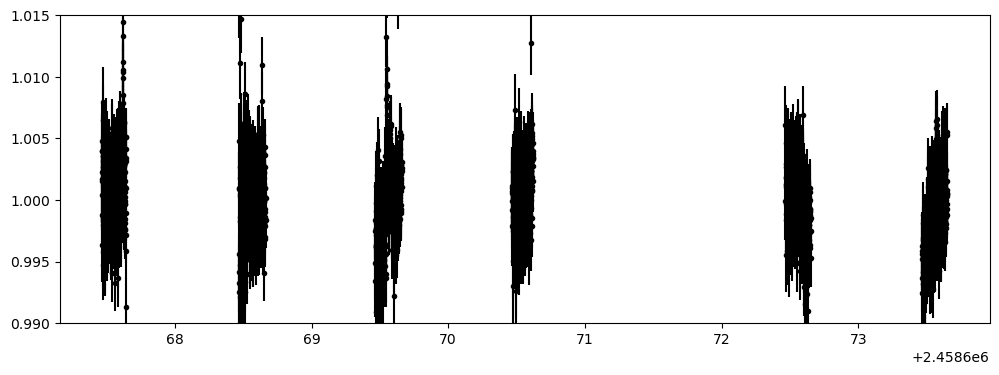

In [2]:
test_case = False

#not used at the moment
pre_bin = False

if test_case:
    t = list(np.linspace(0.5,0.9,200))
    daylength = len(t)
    ndays = 6
    gap = 16/24.
    A = 0.005
    
    for d in range(1,ndays):
        t.extend(np.array(t[:daylength]) + d * (1 + gap))
    
    t = np.array(t)
    ferr = 1e-3 * np.ones(len(t))
    sinusoid_trend = A * np.sin(t)
    f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
    f[22] = 1.01 # add a cosmic
    f[63] = 1.008 # add a cosmic
    f[50] = 0.0 # add a zero flux point

else:
    #file_path = "/Users/fl386/Desktop/SPECULOOS_project/zooniverse/data"
    #files = glob.glob(file_path+"/*")
    #i = 90
    #file_name = files[i]

    file_name = "./Data/0000000000000000001.csv"
    gaia_id = file_name.split("/")[-1].replace(".csv","")

    data = pd.read_csv(file_name)

    mask = (~np.isnan(data["diff_flux_use"])) & (~np.isnan(data["diff_error"])) & (data["diff_error"]>0)
    data = data[mask]
    data.reset_index(drop = True, inplace = True)

    t = data["bjd"].values
    f = data["diff_flux_use"].values
    ferr = data["diff_error"].values
    print(f"nr of measurements: {len(t)}")
    if pre_bin:
        #0.005*24.*60. = 7 minutes
        #some problem if 7 mins or greater (with smaller_binning, problem with units in astropy)
        blc = binning(t, f, bins=0.01, error=ferr, std=True)
        t,f,ferr = blc
        print(f"nr of measurements after binning: {len(t)}")


# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

In [4]:
targ_with_transit = targ.inject_transit(per=2.2*u.d, epoch=0.7 * u.d, inc=90 * u.degree, rp=0.6 * u.R_earth, ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='Flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

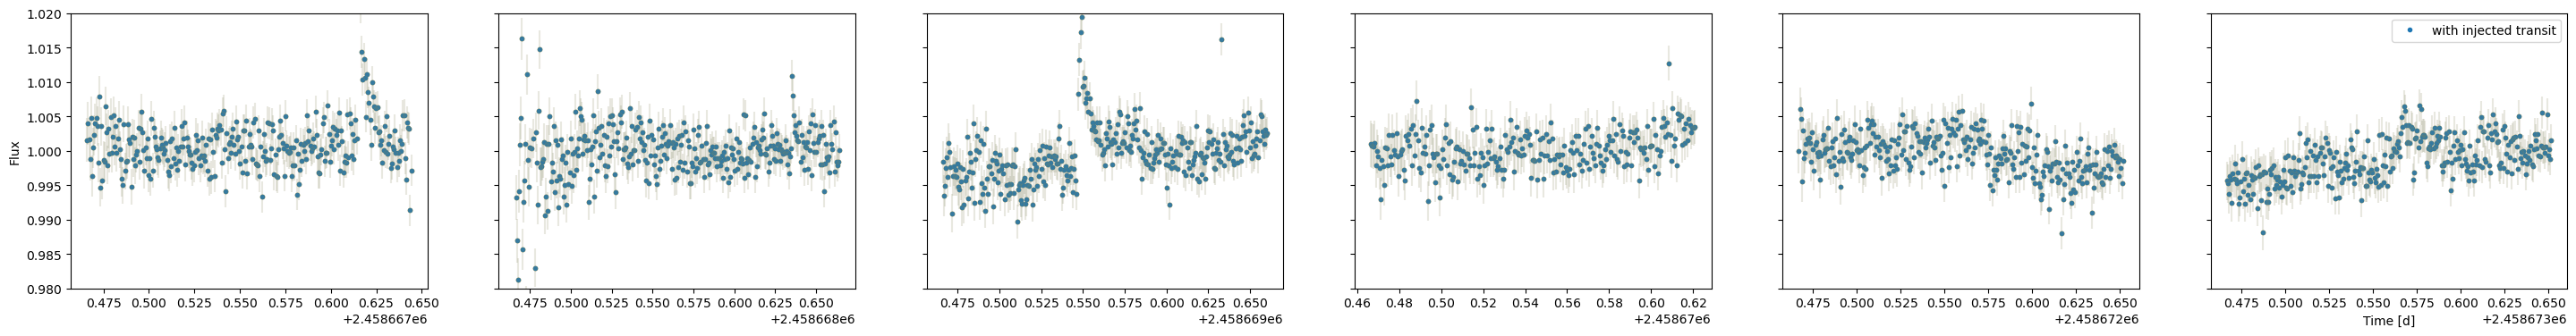

In [5]:
ax=targ.plot(color='orange')
targ_with_transit.plot(ax=ax, label="with injected transit")

In [6]:
targ_with_transit.metadata

{'name': 'test_inject',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'injected_planet': {'period': [<Quantity 2.2 d>],
  'epoch': [<Quantity 0.7 d>],
  'inc': [<Quantity 90. deg>],
  'rp': [<Quantity 0.6 earthRad>],
  'a': [<Quantity 3.30409793 solRad>],
  'a_Rs': [<Quantity 33.04097933>],
  'ld': [[0.3, 0.3]],
  'depth': [<Quantity 0.00302581>],
  'duration': [<Quantity 0.02236399 d>]}}

In [7]:
planets = targ_with_transit.create_lots_of_transit_params(nfake=100, 
                                                          minimum_planet_radius=0.5 * u.R_earth, maximum_planet_radius=3 * u.R_earth,
                                                          minimum_period=0.5 * u.d, maximum_period=1 * u.d,)

In [8]:
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,-0.028163,0.631783,0.001920,1.245606,0.013040664162506177,0.017770,2.458668e+06,1.8706627204803365 solRad,18.706627204803365,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
1,-0.230832,0.496248,0.003954,0.699950,0.0041178650327338044,0.014522,2.458668e+06,1.370512425218378 solRad,13.70512425218378,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
2,-0.058725,0.135089,0.003175,2.086117,0.03657765306495939,0.018550,2.458668e+06,1.7849291564824847 solRad,17.849291564824846,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
3,-0.110236,0.129047,0.006759,2.768179,0.06440610948786711,0.018718,2.458668e+06,1.649227974772117 solRad,16.49227974772117,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
4,-0.152392,0.391572,0.012353,0.931372,0.007290965393538695,0.015503,2.458668e+06,1.5458814512199393 solRad,15.45881451219939,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.187028,0.712842,0.003177,1.911372,0.030706410263718432,0.016595,2.458668e+06,1.4658381867604124 solRad,14.658381867604124,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
96,-0.073019,0.139372,0.006926,1.315222,0.014539068508943358,0.017177,2.458668e+06,1.7461911088765423 solRad,17.461911088765422,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
97,-0.026488,0.656196,0.008806,0.680939,0.0038972266732682104,0.016768,2.458668e+06,1.8754794566611874 solRad,18.754794566611874,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
98,-0.061971,0.644178,0.007615,1.690417,0.02401741234579529,0.017837,2.458668e+06,1.7760568840897155 solRad,17.760568840897154,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None


In [9]:
# pool -> pool_bls
# nuance?
# nfakes = 1 before
# moved time_to_run & nfakes below import time
# rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]


In [10]:
import time

time_to_run = []
nfakes = [8]

for nfake in nfakes:
    start = time.time()
    lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = targ.full_injection_recovery(nfake=nfake, 
                                                                               pool_bls=True, 
                                                                               minimum_planet_radius=0.25 * u.R_earth, 
                                                                               maximum_planet_radius=1 * u.R_earth,
                                                                               minimum_period=0.5 * u.d, 
                                                                               maximum_period=2 * u.d, 
                                                                               recovery_kw = {'condition_on_epoch':1 * u.hour},
                                                                               bls_kw = {"minimum_period":0.5, "maximum_period":10,
                                                                              'transit_durations':np.linspace(0.01, 0.1, 10),
                                                                              'return_all_transits':False,
                                                                              'plot':False},
                                                                               verbose=False)
    
    end = time.time()
    time_to_run.append(end - start)
    print(f"Time elapsed = {(end - start):.2f}s")

Pooling 8 injection-recoveries with 4 cores and kw={'chunksize': 1}.
Planets recovered: 37.5%
But not all of those planets transited during the observation window...
Observed Planets recovered: 42.9%
Time elapsed = 21.74s


Text(0.5, 0, 'Number of injected planets')

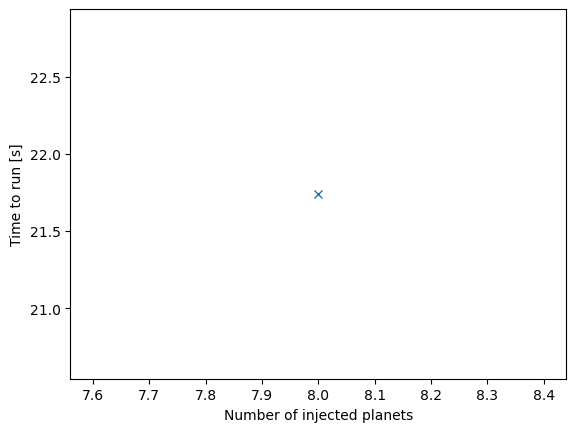

In [11]:
plt.plot(nfakes, time_to_run, 'x-')
plt.ylabel("Time to run [s]")
plt.xlabel("Number of injected planets")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.98, 1.02)

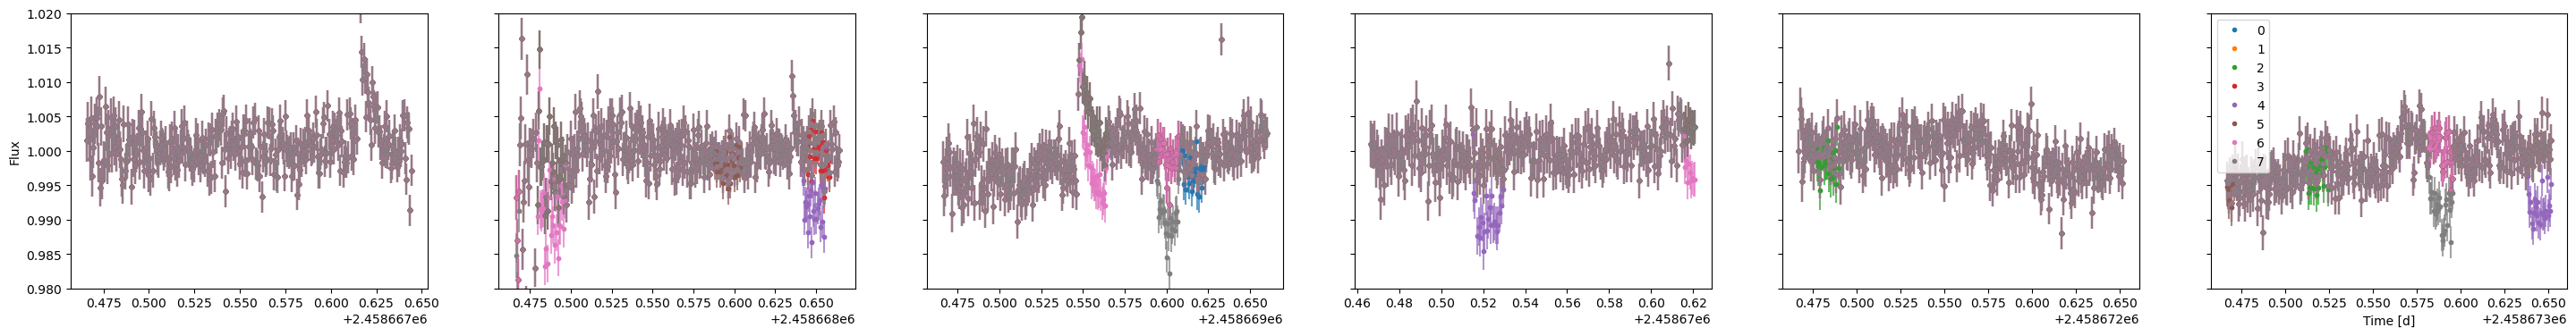

In [12]:
ax=targ.plot()
for i, lc in enumerate(lcs):
    lc.plot(ax=ax, ylims=[0.9,1.1], alpha_error=0.7, color=f"C{i}", label=i)
# plt.legend()
plt.ylim(0.98,1.02)

For whatever reason the pooling doesn't seem to work in Jupyter on my computer...?

In [60]:
# pool = mp.Pool(5)
# lcs = pool.starmap(inject_transit, [(targ, (10**logp) * u.d, phase * 10**logp * u.d, math.acos(cosi) * u.radian,
#                                               rp * u.R_earth, [0.1,0.1]) for
#                                              logp, phase, cosi, rp in zip(planets['logP'], planets['phase'], planets['cosi'],
#                                                                           planets['r_p'])])

In [13]:
planets_df['r_s'].loc[0]

'0.1 solRad'

In [65]:
#rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]

In [14]:
n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3

In [15]:

rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")
# plot_transitparams(results[4]['r_p'], results[4]['depth'] * np.sqrt(n_points_in_transit)/lc_noise, results[4]['recovered'], xlabel="Radius", ylabel="SNR", zlabel="Detected?", ylims=[], yscale='uniform',
#                        xscale='uniform', add_points={}, svname="")

TypeError: can't multiply sequence by non-int of type 'float'

Print recovery stats:

In [16]:
print(f"Planets recovered: {100 * len(planets_df.loc[planets_df['recovered'] == 1.0]) /  len(planets_df['recovered'])}%")
print("But not all of those planets transited during the observation window...")
print(f"""Observed Planets recovered: {100 * len(planets_df.loc[(planets_df['recovered'] == 1.0) & 
            (planets_df['observed'] == 1.0)]) /  len(planets_df['recovered'][planets_df['observed']==1.0])}%""")

Planets recovered: 37.5%
But not all of those planets transited during the observation window...
Observed Planets recovered: 42.857142857142854%


Plot only the planets which were observed:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


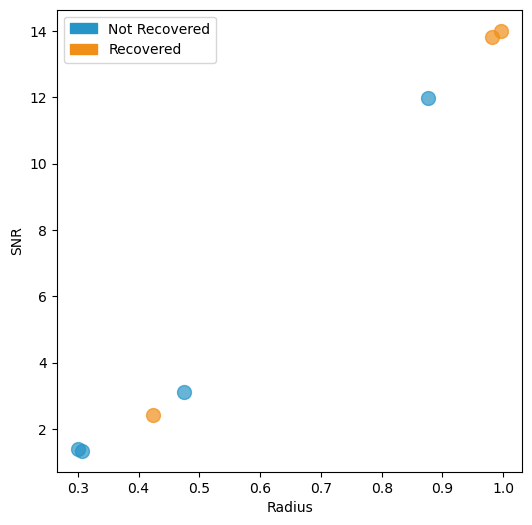

In [17]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Radius", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=100,
                   svname="")